In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE_DIR = Path('../../').resolve()
DATOS_LIMPIOS = BASE_DIR / "Datos" / "Datos_limpios"
IMAGENES = BASE_DIR / "imagenes"

carreras = ["Matemáticas", "Física"]

# Configuración visual
sns.set_theme(style="whitegrid")

Analizando censura para: Matemáticas


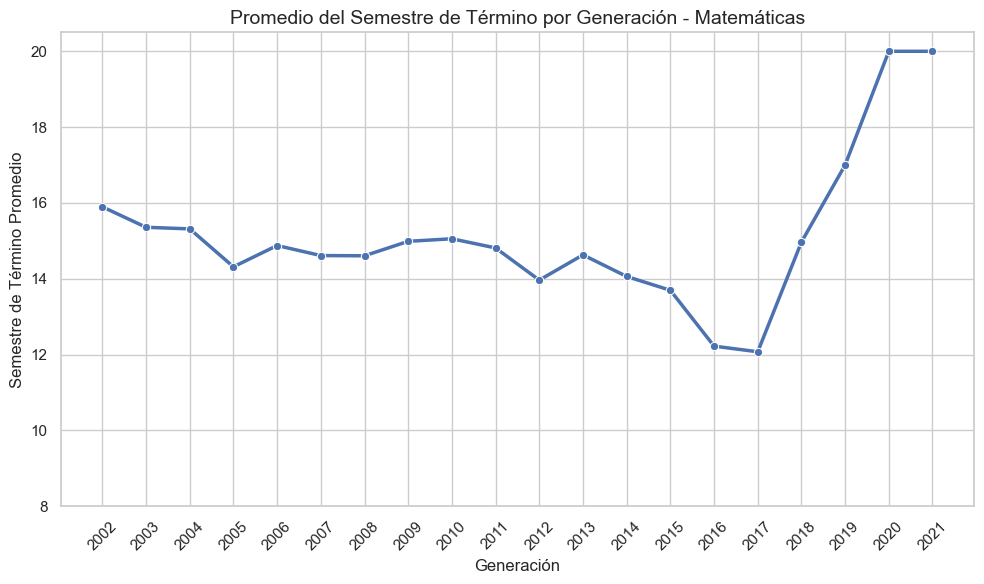

/var/folders/w0/_lcj6zm17mj_rm01mzkhtkyc0000gn/T/ipykernel_94352/2642426357.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Generación', y='semestre_termino', palette="viridis")


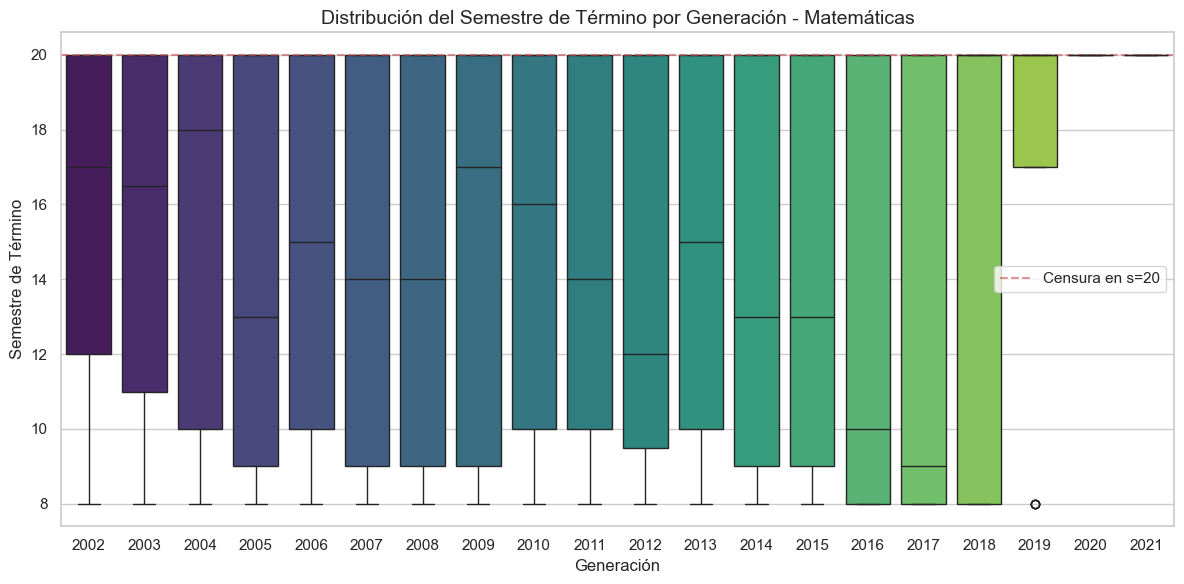

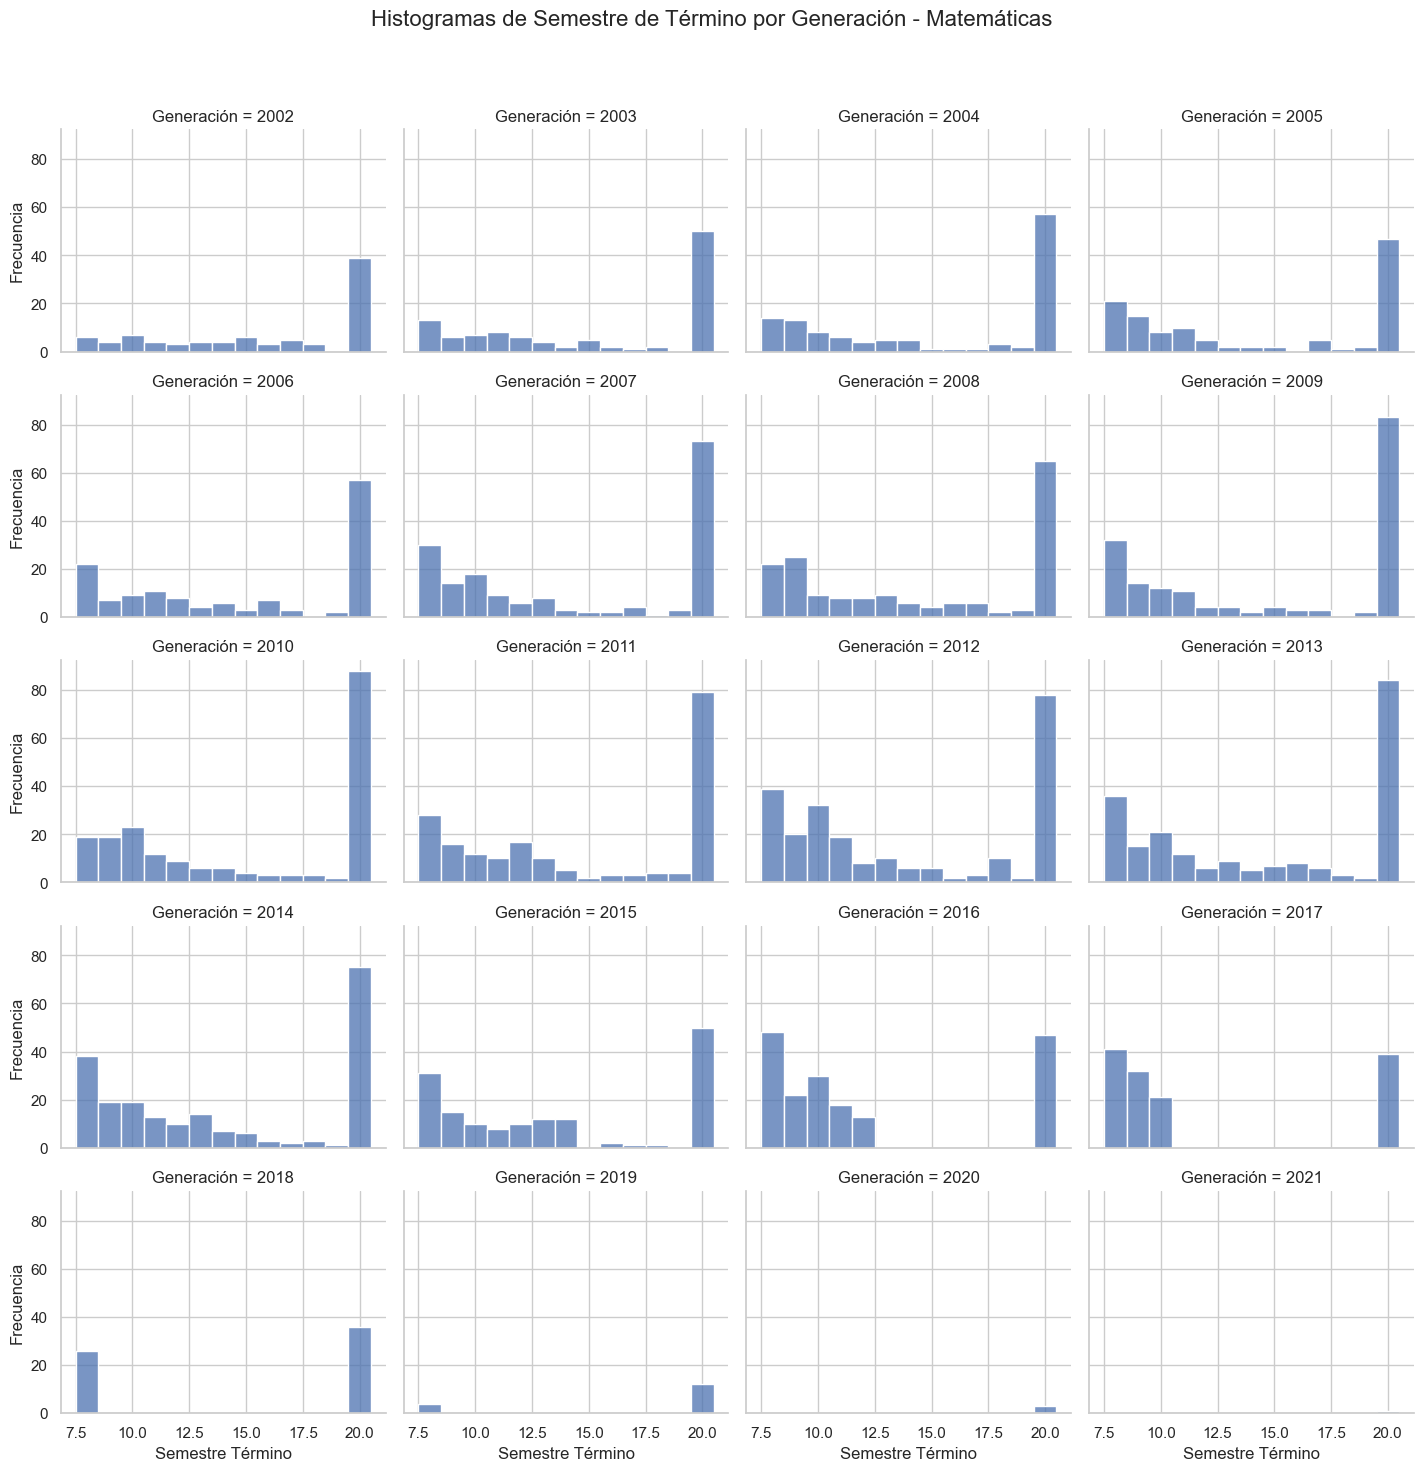

Analizando censura para: Física


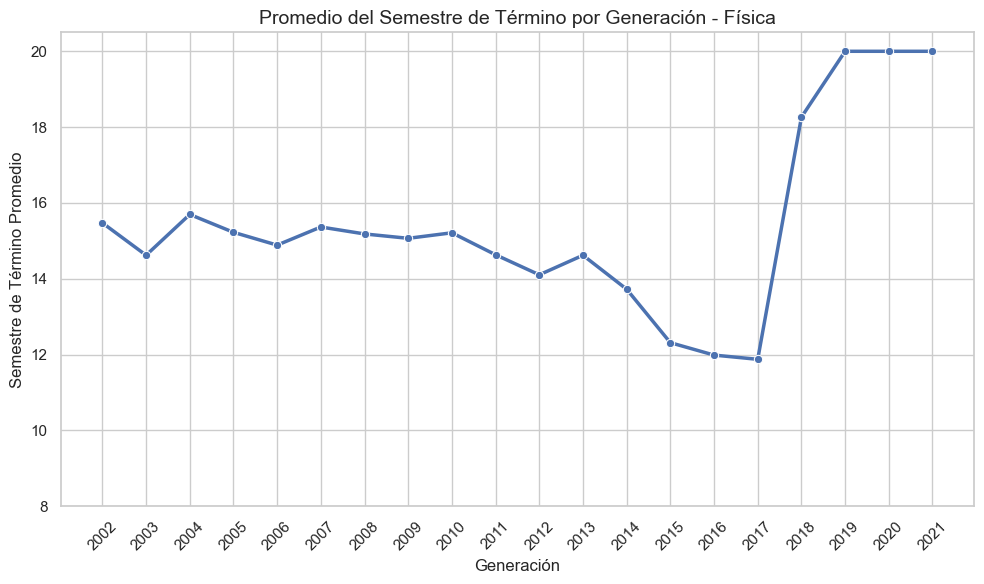

/var/folders/w0/_lcj6zm17mj_rm01mzkhtkyc0000gn/T/ipykernel_94352/2642426357.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Generación', y='semestre_termino', palette="viridis")


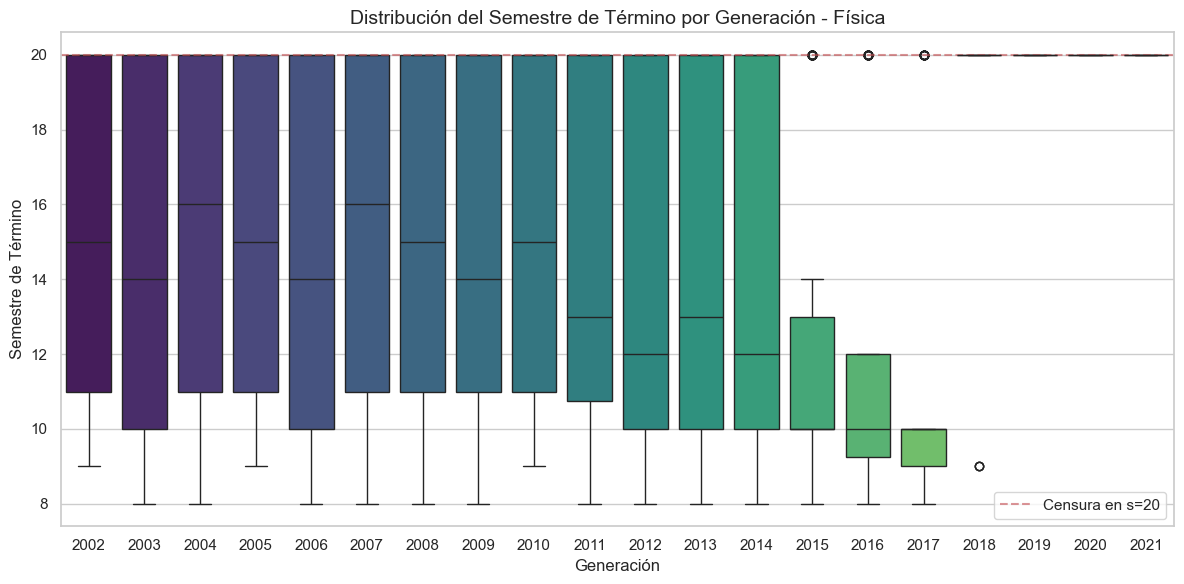

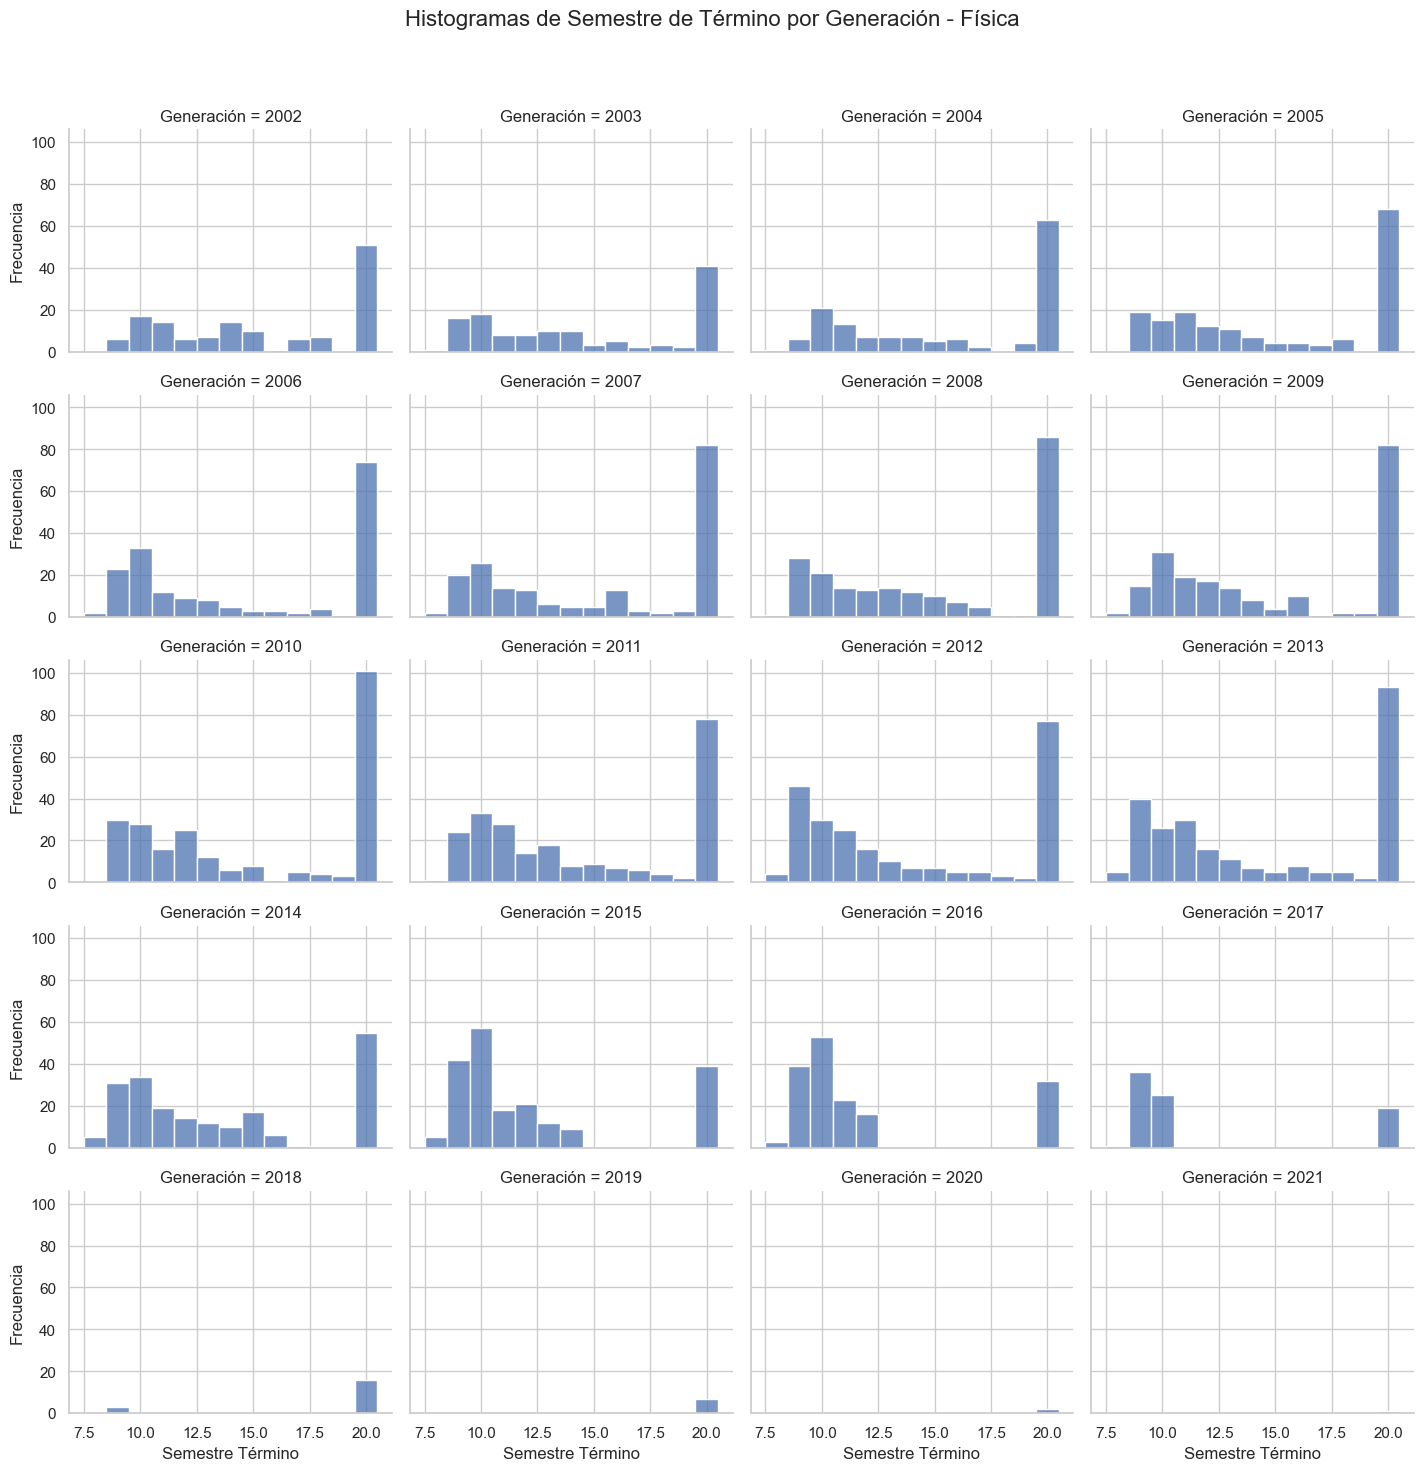

Análisis de censura completado.


In [2]:
for carrera in carreras:
    print(f"Analizando censura para: {carrera}")
    archivo = DATOS_LIMPIOS / f"{carrera}.xlsx"
    
    if not archivo.exists():
        continue

    df = pd.read_excel(archivo)
    
    # Asegurar que Generación sea tratada de forma correcta (numérica u ordinal)
    df = df.dropna(subset=['Generación'])
    df['Generación'] = df['Generación'].astype(int)
    
    # 1. Gráfica de Promedio de Titulación por Generación
    plt.figure(figsize=(10, 6))
    promedios = df.groupby('Generación')['semestre_termino'].mean().reset_index()
    sns.lineplot(data=promedios, x='Generación', y='semestre_termino', marker='o', linewidth=2.5)
    plt.title(f"Promedio del Semestre de Término por Generación - {carrera}", fontsize=14)
    plt.xlabel("Generación", fontsize=12)
    plt.ylabel("Semestre de Término Promedio", fontsize=12)
    plt.ylim(8, 20.5)
    plt.xticks(promedios['Generación'].unique(), rotation=45)
    plt.tight_layout()
    plt.savefig(IMAGENES / f"promedio_titulacion_gen_{carrera.lower().replace('á', 'a').replace('í', 'i')}.png", dpi=300)
    plt.show()

    # 2. Histograma del semestre de término por Generación (Usando Boxplot para ver la distribución completa)
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='Generación', y='semestre_termino', palette="viridis")
    plt.title(f"Distribución del Semestre de Término por Generación - {carrera}", fontsize=14)
    plt.xlabel("Generación", fontsize=12)
    plt.ylabel("Semestre de Término", fontsize=12)
    plt.axhline(y=20, color='r', linestyle='--', alpha=0.6, label='Censura en s=20')
    plt.legend()
    plt.tight_layout()
    plt.savefig(IMAGENES / f"boxplot_censura_gen_{carrera.lower().replace('á', 'a').replace('í', 'i')}.png", dpi=300)
    plt.show()
    
    # 3. Histograma Facetado (Grid) para ver la masa desplazándose a 20
    g = sns.FacetGrid(df, col="Generación", col_wrap=4, height=3, aspect=1.2)
    g.map(sns.histplot, "semestre_termino", bins=np.arange(7.5, 21.5, 1), kde=False)
    g.fig.subplots_adjust(top=0.9)
    g.fig.suptitle(f"Histogramas de Semestre de Término por Generación - {carrera}", fontsize=16)
    g.set_axis_labels("Semestre Término", "Frecuencia")
    plt.savefig(IMAGENES / f"hist_gen_{carrera.lower().replace('á', 'a').replace('í', 'i')}.png", dpi=300)
    plt.show()

print("Análisis de censura completado.")